In [1]:
from ultralytics import YOLO
import os
import config
import matplotlib.pyplot as plt
import cv2

In [2]:
print(config.ANOMALY_MODEL_NAME)
model = YOLO(config.ANOMALY_MODEL_NAME)
print(f"Model loaded")

object_model\anomaly_model_v1.pt
Model loaded



image 1/1 e:\Projects\CCTV_horkang\sample_data\test_img\test_12_1.png: 384x640 (no detections), 31.8ms
Speed: 1.5ms preprocess, 31.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
File: test_12_1.png | Anomalies detected: 0


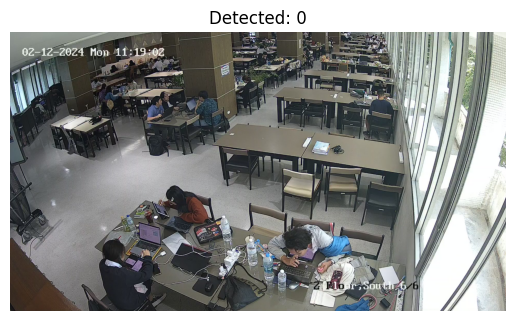


image 1/1 e:\Projects\CCTV_horkang\sample_data\test_img\test_3_1.jpg: 384x640 1 backpack, 11.3ms
Speed: 1.9ms preprocess, 11.3ms inference, 7.8ms postprocess per image at shape (1, 3, 384, 640)
File: test_3_1.jpg | Anomalies detected: 1


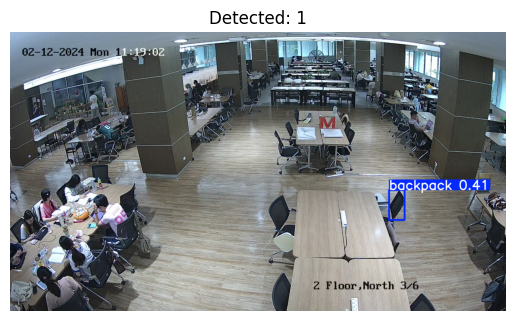


image 1/1 e:\Projects\CCTV_horkang\sample_data\test_img\test_4_1.png: 384x640 (no detections), 18.9ms
Speed: 1.3ms preprocess, 18.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
File: test_4_1.png | Anomalies detected: 0


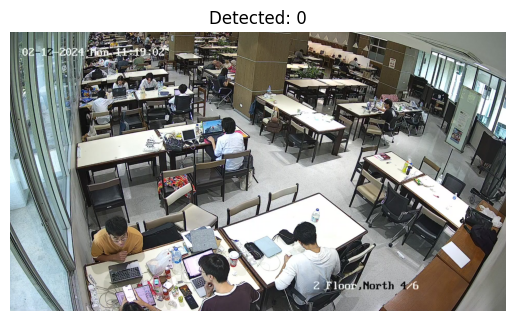


image 1/1 e:\Projects\CCTV_horkang\sample_data\test_img\test_9_1.png: 384x640 (no detections), 17.1ms
Speed: 2.0ms preprocess, 17.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
File: test_9_1.png | Anomalies detected: 0


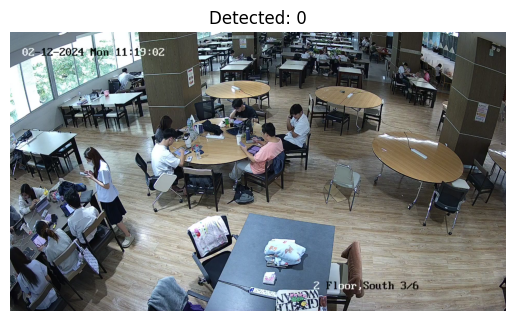

In [3]:
folder_path = 'sample_data/test_img'

images = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
for img_name in images:
    full_path = os.path.join(folder_path, img_name)
    results = model(full_path)
    for r in results:
        count = len(r.boxes)
        print(f"File: {img_name} | Anomalies detected: {count}")
        
        # Optional: Show the first 3 images to verify
        # (Using a counter here avoids flooding your notebook if you have 1000 images)
        annotated_img = r.plot()
        rgb_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_img)
        plt.title(f"Detected: {count}")
        plt.axis('off')
        plt.show()